In [7]:
!pip install librosa --quiet

In [16]:
!pip install scikit-image --quiet

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
kaggleURL = "https://www.kaggle.com/datasets/"
kaggleDataset = "benfitzgerald3132/jazz-vs-classical-music-classification"
od.download(kaggleURL + kaggleDataset)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  spirosh


Your Kaggle Key:

  ········


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/benfitzgerald3132/jazz-vs-classical-music-classification


100%|███████████████████████████████████████████████████████████████████████████████| 0.98G/0.98G [00:01<00:00, 919MB/s]


In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import os
import time
from skimage.transform import resize
import matplotlib.pyplot as plt

device =  'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [2]:
# Define folder paths
classical_folder = 'jazz-vs-classical-music-classification' + '/dataset/' + 'Classical'
jazz_folder = 'jazz-vs-classical-music-classification' + '/dataset/' + 'Jazz'

# Function to get .wav files and assign label
def get_labeled_files(folder_path, label):
    files = [
        {"filename": os.path.join(folder_path, f), "label": label}
        for f in os.listdir(folder_path)
        if f.endswith(".wav")
    ]
    return files

# Get labeled file lists
classical_files = get_labeled_files(classical_folder, "classical")
jazz_files = get_labeled_files(jazz_folder, "jazz")

#To get only the filename uncomment the following two lines
#for f in classical_files: f['filename'] = f['filename'].replace(classical_folder + '/', '')
#for f in jazz_files: f['filename'] = f['filename'].replace(jazz_folder + '/', '')

all_files = classical_files + jazz_files
df = pd.DataFrame(all_files)

df = df.rename(columns={'filename': 'FilePath'})
df = df.rename(columns={'label': 'Class'})

# Show the result
print(df)

                                               FilePath      Class
0     jazz-vs-classical-music-classification/dataset...  classical
1     jazz-vs-classical-music-classification/dataset...  classical
2     jazz-vs-classical-music-classification/dataset...  classical
3     jazz-vs-classical-music-classification/dataset...  classical
4     jazz-vs-classical-music-classification/dataset...  classical
...                                                 ...        ...
1446  jazz-vs-classical-music-classification/dataset...       jazz
1447  jazz-vs-classical-music-classification/dataset...       jazz
1448  jazz-vs-classical-music-classification/dataset...       jazz
1449  jazz-vs-classical-music-classification/dataset...       jazz
1450  jazz-vs-classical-music-classification/dataset...       jazz

[1451 rows x 2 columns]


In [5]:
print(df['Class'].unique())

['classical' 'jazz']


In [6]:
print('Data Shape:', df.shape)
print('Class Distribution:', df['Class'].value_counts())

Data Shape: (1451, 2)
Class Distribution: Class
classical    726
jazz         725
Name: count, dtype: int64


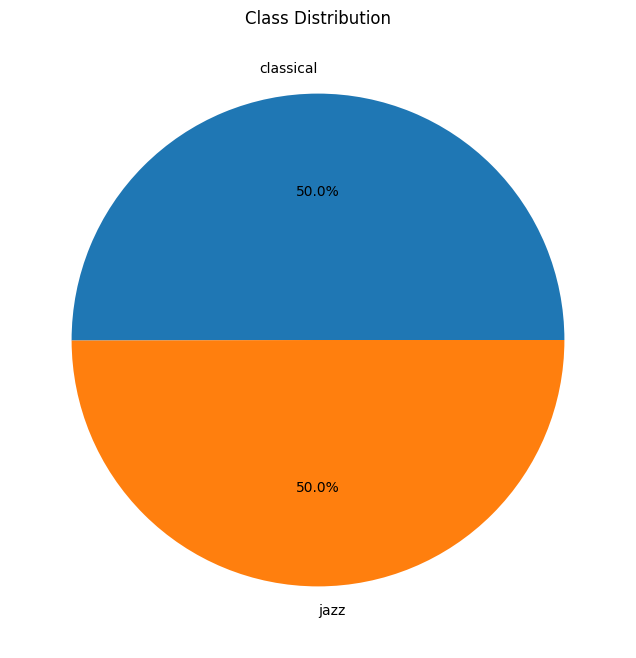

In [7]:
plt.figure(figsize = (8,8))
plt.pie(df['Class'].value_counts(), labels = df['Class'].value_counts().index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.show()

In [8]:
label_encoder = LabelEncoder()
df['Class'] = label_encoder.fit_transform(df['Class'])

train = df.sample(frac=0.7, random_state=7)
test = df.drop(train.index)

val = test.sample(frac=0.5, random_state=7)
test = test.drop(val.index)

print('Train Data Shape:',train.shape)
print('Val Data Shape:',val.shape)
print('Test Data Shape:',test.shape)

Train Data Shape: (1016, 2)
Val Data Shape: (218, 2)
Test Data Shape: (217, 2)


In [14]:
class CustomAudioDataset(Dataset):
  def __init__(self, dataframe):
    self.dataframe = dataframe
    
    # --- CHANGE 1: Eager load ONLY the labels and file paths ---
    # Labels are small, so loading them is fine.
    self.labels = torch.LongTensor(list(dataframe["Class"]))
    
    # Store the file paths, NOT the loaded audio.
    self.file_paths = list(dataframe['FilePath'])

    # --- Store constants here for easy access ---
    self.sr = 22050
    self.duration = 5
    self.img_height = 128
    self.img_width = 256

  def __len__(self):
    return len(self.file_paths) # More direct than dataframe.shape[0]

  def __getitem__(self, idx):
    # --- CHANGE 2: Load and process the audio file ON DEMAND ---
    # This is "lazy loading".
    file_path = self.file_paths[idx]
    spectrogram = self.get_spectrogram(file_path)
    
    # Convert numpy array from get_spectrogram to a FloatTensor
    audio_tensor = torch.from_numpy(spectrogram).type(torch.FloatTensor)
    
    # Add the channel dimension for the CNN
    audio_tensor = audio_tensor.unsqueeze(0)
    
    # Get the corresponding label. It's already a tensor.
    label = self.labels[idx]
    
    # Note: We do NOT move to `device` here. The training loop does that.
    # It's more efficient to move the whole batch to the GPU at once.
    return audio_tensor, label

  def get_spectrogram(self, file_path):
    # Load the audio file
    signal, sr = librosa.load(file_path, sr=self.sr, duration=self.duration)

    # Pad shorter signals to ensure consistent length
    required_length = self.sr * self.duration
    if len(signal) < required_length:
        signal = np.pad(signal, (0, required_length - len(signal)), 'constant')

    # Compute the spectrogram
    spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=self.img_height)

    # Convert the spectrogram to dB scale
    spec_db = librosa.power_to_db(spec, ref=np.max)

    # --- CHANGE 3: Resize to a fixed dimension ---
    # The fix_length line has been removed as it was incorrect.
    spec_resized = resize(spec_db, (self.img_height, self.img_width), anti_aliasing=True)
    
    return spec_resized

In [15]:
train_dataset = CustomAudioDataset(dataframe = train)
val_dataset = CustomAudioDataset(dataframe = val)
test_dataset = CustomAudioDataset(dataframe = test)

In [16]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [17]:
train_dataloader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle=True)

In [24]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Convolutional Layers ---
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pooling = nn.MaxPool2d(2, 2)

        # --- Flattening Layer ---
        self.flatten = nn.Flatten()
        
        # --- Fully-Connected (Linear) Layers ---
        # CORRECTED: Changed names to lowercase for consistency
        # The input size 64 * 16 * 32 is correct if your input spectrogram is 128x256.
        # After 3 pooling layers (128 -> 64 -> 32 -> 16) and (256 -> 128 -> 64 -> 32)
        # the shape will be [batch, 64, 16, 32]
        self.linear1 = nn.Linear(64 * 16 * 32, 4096)
        self.linear2 = nn.Linear(4096, 1024)
        self.linear3 = nn.Linear(1024, 512)
        self.output = nn.Linear(512, len(df['Class'].unique()))

        # --- Dropout Layer ---
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # --- Convolutional Block ---
        # Apply ReLU activation after each convolution
        x = self.pooling(F.relu(self.conv1(x)))
        x = self.pooling(F.relu(self.conv2(x)))
        x = self.pooling(F.relu(self.conv3(x)))

        # --- Classifier Block ---
        x = self.flatten(x)
        
        # CORRECTED: Used lowercase names and proper sequence
        # IMPROVEMENT: Added ReLU after each linear layer
        x = self.dropout(F.relu(self.linear1(x)))
        x = self.dropout(F.relu(self.linear2(x)))
        x = self.dropout(F.relu(self.linear3(x))) # CORRECTED: Changed from linear4 to linear3
        
        # The final output layer should not have a ReLU, as CrossEntropyLoss expects raw logits.
        x = self.output(x)
    
        return x

# Re-create the model instance with the corrected class and move it to the device
model = Net().to(device)

# This will now print the corrected structure
print(model)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [25]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss
optimizer = Adam(model.parameters(), lr=LR) # Adam optimizer

In [26]:
total_loss_train_plot = [] # Empty list to be filled with train loss after each epoch
total_loss_validation_plot = [] # Empty list to be filled with validation loss after each epoch
total_acc_train_plot = [] # Empty list to be filled with train accuracy after each epoch
total_acc_validation_plot = [] # Empty list to be filled with validation accuracy after each epoch


for epoch in range(EPOCHS):
  start_time = time.time() # We use this to calculate the time of each epoch, it starts a counter once called
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_dataloader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for inputs, labels in val_dataloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  epoch_string = f"""
                  Epoch: {epoch+1}/{EPOCHS}, 
                  Train Loss: {round(total_loss_train/100, 4)}, 
                  Train Accuracy: {round((total_acc_train/train_dataset.__len__() * 100), 4)}, 
                  Validation Loss: {round(total_loss_val/100, 4)}, 
                  Validation Accuracy: {round((total_acc_val/val_dataset.__len__() * 100), 4)}
                  """
  print(epoch_string)
  print("="*30)
     


                  Epoch: 1/25, 
                  Train Loss: 0.6644, 
                  Train Accuracy: 53.0512, 
                  Validation Loss: 0.0962, 
                  Validation Accuracy: 56.422
                  

                  Epoch: 2/25, 
                  Train Loss: 0.4199, 
                  Train Accuracy: 62.4016, 
                  Validation Loss: 0.0833, 
                  Validation Accuracy: 73.3945
                  

                  Epoch: 3/25, 
                  Train Loss: 0.3608, 
                  Train Accuracy: 71.4567, 
                  Validation Loss: 0.0786, 
                  Validation Accuracy: 76.1468
                  

                  Epoch: 4/25, 
                  Train Loss: 0.319, 
                  Train Accuracy: 77.1654, 
                  Validation Loss: 0.0663, 
                  Validation Accuracy: 76.6055
                  

                  Epoch: 5/25, 
                  Train Loss: 0.2613, 
                  Train Ac

In [29]:
#TESTING BLOCK ---

model.eval() # >>> FIX 1: Set the model to evaluation mode. CRITICAL!

with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  
  for inputs, labels in test_dataloader:
    
    # Move the data to the same device as the model
    inputs, labels = inputs.to(device), labels.to(device)

    prediction = model(inputs)
    
    # Calculate the loss on the test set
    loss = criterion(prediction, labels)
    total_loss_test += loss.item()

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

# Calculate average loss and accuracy
avg_test_loss = total_loss_test / len(test_dataloader)
avg_test_acc = total_acc_test / len(test_dataset)

print("="*30)
print("TESTING RESULTS:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {avg_test_acc*100:.2f}%")
print("="*30)

TESTING RESULTS:
Test Loss: 0.7284
Test Accuracy: 88.94%


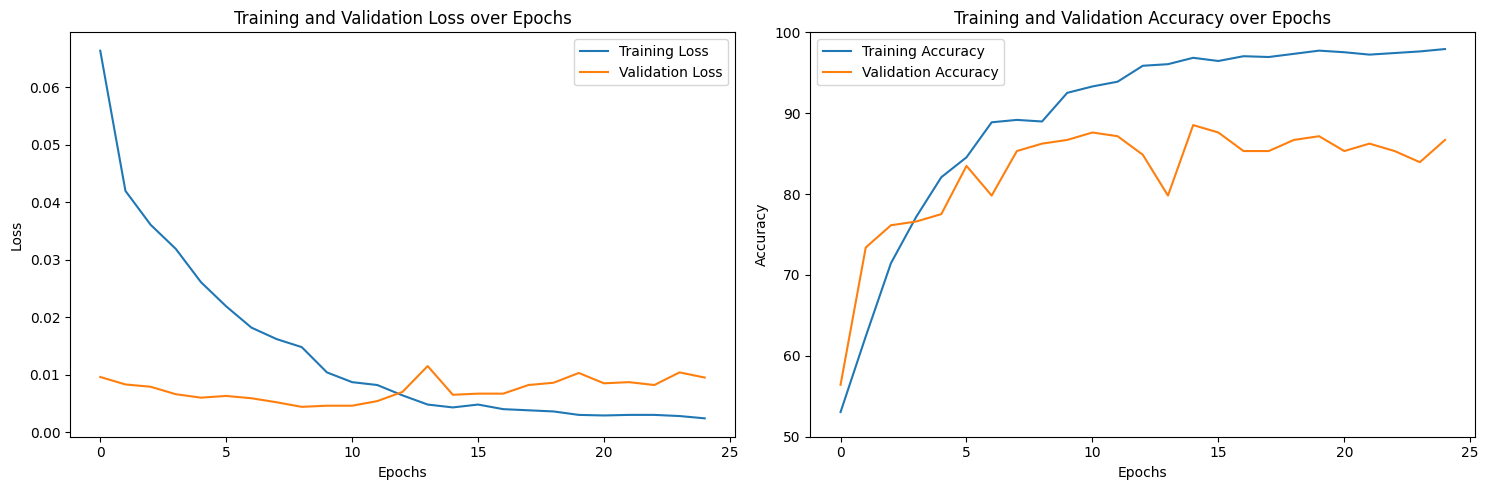

In [32]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[1].set_ylim([0, 0.7])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([50, 100])
axs[1].legend()

plt.tight_layout()

plt.show()